---
# Henon 4D,  Invariant Tori
---

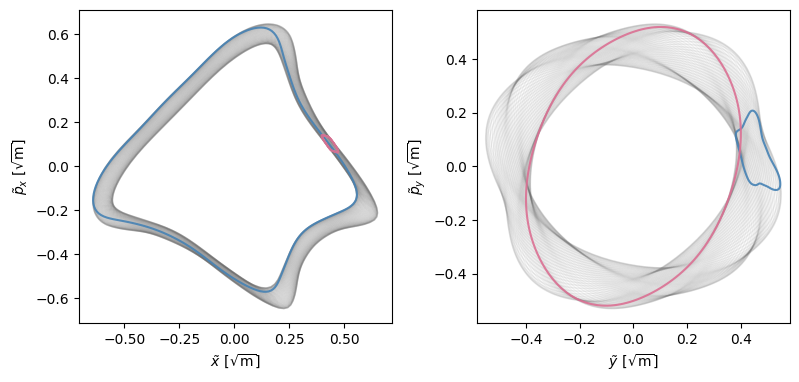

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import nafflib
import pytori as pt
import pytori.plotting as ptplt

# ========================
# Henon 4D parameters
num_turns   = int(2e4)
coupling = 0.3
Qx0 = 0.25 - 2*np.sqrt(2)/1000
Qy0 = np.sqrt(2) - 1
# ========================


# Non-resonant initial conditions
x_start    = np.array([0.4])
px_start   = 0.35 * x_start
y_start    = np.array([0.4])
py_start   = 0.35 * y_start

tori    = []
for x0, px0, y0, py0 in zip(x_start, px_start,y_start, py_start):
    # Iterating Henon map
    x,px,y,py = nafflib.henon_map_4D(x0,px0,y0,py0, Qx = Qx0,
                                                    Qy = Qy0,
                                                    coupling = coupling,
                                                    num_turns= num_turns)
    dct = {'x':x,'px':px,'y':y,'py':py}

    # Extracting harmonics:
    #============================================================================
    n_harm  = 100
    w_order = 4
    Qvec   = [nafflib.tune(dct[plane],dct[f'p{plane}'],window_order=w_order) for plane in ['x','y']]
    Ax,Qx  = nafflib.harmonics( dct['x'],dct[f'px'],num_harmonics = n_harm,window_order=w_order)
    Ay,Qy  = nafflib.harmonics( dct['y'],dct[f'py'],num_harmonics = n_harm,window_order=w_order)
    #============================================================================

    # Indexing harmonics
    #============================================================================
    max_n       = 90
    max_alias   = 50
    warning_tol = 1e-7
    nx  = nafflib.linear_combinations(Qx,Qvec = Qvec,max_n=max_n,max_alias=max_alias,warning_tol=warning_tol)
    ny  = nafflib.linear_combinations(Qy,Qvec = Qvec,max_n=max_n,max_alias=max_alias,warning_tol=warning_tol)
    #============================================================================

    # Building torus (2D-torus)
    #============================================================================
    _torus = pt.Torus.from_naff(n=[nx,ny],A=[Ax,Ay])
    tori.append(_torus)
    #============================================================================


torus = tori[0]

# Plotting
#--------------------------------------------------
x_color = 'steelblue'
y_color = 'palevioletred'

fig, axes = plt.subplots(1, 2, figsize=(8.1,4))

# TORUS SHADOW, plotting all possible angle values
#=======================================================
T_loop = np.linspace(0,2*np.pi,100)
T_vals = np.linspace(0,2*np.pi,80)

plt.sca(axes[0])
for T0 in T_vals[:-1]:
    ptplt.loop(torus,proj='x',Tx=T_loop,Ty=T0,edgecolor='dimgrey',alpha=0.1,lw=1)

plt.sca(axes[1])
for T0 in T_vals[:-1]:
    ptplt.loop(torus,proj='y',Tx=T0,Ty=T_loop,edgecolor='dimgrey',alpha=0.1,lw=1)
#=======================================================


# Plotting a specific loop
#=======================================================
plt.sca(axes[0])
# same as ptplt.xloop(torus,looping='x')
ptplt.loop(torus,proj='x',looping='x',edgecolor=x_color,alpha=0.9,lw=1.5)
ptplt.loop(torus,proj='x',looping='y',edgecolor=y_color,alpha=0.9,lw=1.5)

plt.sca(axes[1])
# same as ptplt.yloop(torus,looping='x')
ptplt.loop(torus,proj='y',looping='x',edgecolor=x_color,alpha=0.9,lw=1.5)
ptplt.loop(torus,proj='y',looping='y',edgecolor=y_color,alpha=0.9,lw=1.5)


for ax,plane in zip(axes,['x','y']):
    plt.sca(ax)
    plt.axis('equal')
    plt.gca().set_box_aspect(1) 
    plt.xlabel(rf'$\tilde {plane}\ [\sqrt{{\mathrm{{m}}}}]$');
    plt.ylabel(rf'$\tilde p_{plane}\ [\sqrt{{\mathrm{{m}}}}]$');
plt.tight_layout()

---
# Inspecting Torus and Fourier Series
---

In [2]:
# Display parameters can be changed globally
from pytori.display import DISPLAY_FMT,HAS_RICH
DISPLAY_FMT.fmt     = ".5f"   
DISPLAY_FMT.n_terms = 10

# Choosing example torus and displaying
torus = tori[0]
display(torus)

# We can also inspect a specific projection
display(torus.x)

╭─────────────────────────────────────────────── Torus (FourierSeries) ────────────────────────────────────────────────╮
│                                                                                                                      │
│  ╭──────────────────── x ────────────────────╮             ╭──────────────────── y ────────────────────╮             │
│  │                                           │             │                                           │             │
│  │   Index     Value               Norm      │             │   Index     Value               Norm      │             │
│  │   ( 1, 0)  -0.44712 - 0.24146j  0.50816   │             │   ( 0, 1)  -0.45206 - 0.04766j  0.45457   │             │
│  │   ( 0, 0)   0.05454 + 0.05358j  0.07646   │             │   (-1,-1)  -0.05044 - 0.05602j  0.07538   │             │
│  │   (-3, 0)   0.00791 + 0.06513j  0.06561   │             │   (-1, 1)  -0.01031 - 0.02411j  0.02622   │             │
│  │   ( 2, 0)   0.01088 + 0.05477j  0.05584   │             │   ( 1, 1)  -0.00469 - 0.02386j  0.02432   │             │
│  │   (-2, 0)  -0.05067 - 0.00913j  0.05149   │             │   ( 1,-1)  -0.00253 - 0.01866j  0.01883   │             │
│  │   ( 0,-2)  -0.03313 - 0.01590j  0.03675   │             │   ( 3,-1)   0.00354 + 0.00709j  0.00792   │             │
│  │   ( 5, 0)  -0.01709 - 0.01443j  0.02237   │             │   (-2,-1)   0.00294 + 0.00492j  0.00574   │             │
│  │   (-4, 0)   0.01816 + 0.00811j  0.01988   │             │   (-4, 1)   0.00150 + 0.00543j  0.00563   │             │
│  │   ( 4, 0)  -0.00657 - 0.01545j  0.01679   │             │   ( 2, 1)   0.00423 + 0.00227j  0.00480   │             │
│  │   ( 0, 2)  -0.00399 - 0.00794j  0.00889   │             │   ( 2,-1)   0.00426 + 0.00071j  0.00431   │             │
│  │   ...      ...                  ...       │             │   ...      ...                  ...       │             │
│  │                                           │             │                                           │             │
│  ╰──────────────── terms=100 ────────────────╯             ╰──────────────── terms=100 ────────────────╯             │
│                                                                                                                      │
╰── dim=2, β₀=(1, 1, 1), (Ix,Iy)=(0.121, 0.0997), max_order=None, max_terms=100, numerical_tol=None, backend='numpy' ──╯

╭───────────────────────────────────────── FourierSeries ──────────────────────────────────────────╮
│                                                                                                  │
│   Index     Value               Norm                                                             │
│   ( 1, 0)  -0.44712 - 0.24146j  0.50816                                                          │
│   ( 0, 0)   0.05454 + 0.05358j  0.07646                                                          │
│   (-3, 0)   0.00791 + 0.06513j  0.06561                                                          │
│   ( 2, 0)   0.01088 + 0.05477j  0.05584                                                          │
│   (-2, 0)  -0.05067 - 0.00913j  0.05149                                                          │
│   ( 0,-2)  -0.03313 - 0.01590j  0.03675                                                          │
│   ( 5, 0)  -0.01709 - 0.01443j  0.02237                                                          │
│   (-4, 0)   0.01816 + 0.00811j  0.01988                                                          │
│   ( 4, 0)  -0.00657 - 0.01545j  0.01679                                                          │
│   ( 0, 2)  -0.00399 - 0.00794j  0.00889                                                          │
│   ...      ...                  ...                                                              │
│                                                                                                  │
╰────── dim=2, terms=100, max_order=None, max_terms=100, numerical_tol=None, backend='numpy' ──────╯

---
# Torus visualization
---

This example needs cleanup but is already a working example of how to plot and visualize 4D tori. 
Note that some tricks are needed to manually adjust the zorder of rendered polygons since Matplotlib does not do a great job in 3D axis...
For more robust visuals, the torus can be exported to Blender using some additionnal python scripts (see pytori/legacy/blender)


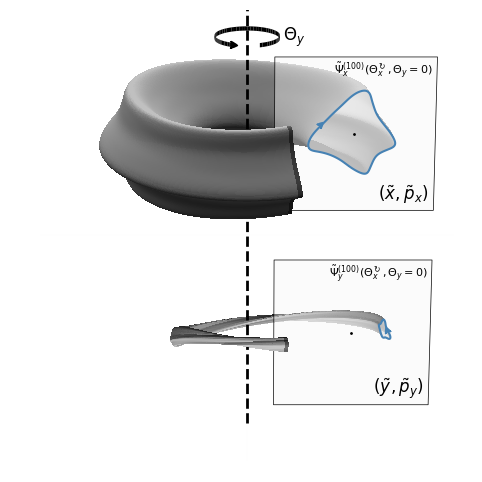

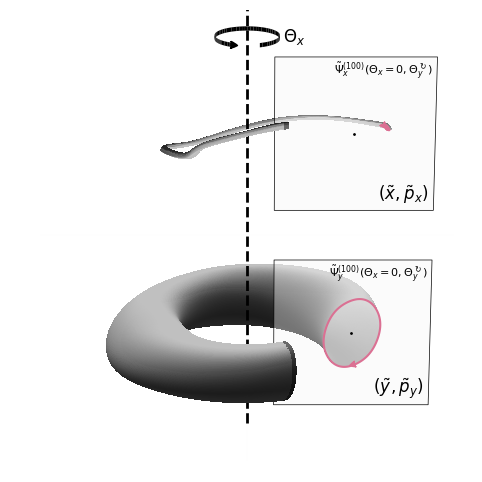

In [3]:
Psi = torus.copy()
for obs in ['x','y']:

    num_slices = 300
    num_angles = 300
    torus_r = 3*np.sqrt(2*Psi.Ix)

    if obs == 'x':
        rot_around = 'y'
        Tx0,Ty0 = 0,0
        Tx_vec = np.linspace(0,2*np.pi,num_angles)
        Ty_vec = Ty0
    elif obs == 'y':
        rot_around = 'x'
        Tx0,Ty0 = 0,0
        Tx_vec = Tx0
        Ty_vec = np.linspace(0,2*np.pi,num_angles)

    fig = plt.figure(figsize=(12, 6))

    # Setting 3d projection
    #-------------------------------------
    ax = fig.add_subplot(projection='3d',computed_zorder=False)
    ax.view_init(elev=20, azim=-90,roll=0) 
    ax.set_box_aspect([1, 1, 1])
    #-------------------------------------

    # Lighting
    #-------------------------------------
    lights = [
        (ptplt.LightSource(azdeg=0, altdeg=60), 1),   # Key light
        (ptplt.LightSource(azdeg=0, altdeg=-90), 0.2),  # Fill light
        (ptplt.LightSource(azdeg=270, altdeg=10), 0),  # Rim light
    ]
    #-------------------------------------



    # Plot Torus and scale axis
    #-------------------------------------
    tori_collection = []
    tori_mesh       = []
    tori_fc         = []
    tags            = []
    for projection,z_offset in zip([f'{obs}x',f'{obs}y'],[torus_r,-torus_r]):

        dT = np.pi/100
        for tt,color,zorder in zip([np.linspace(0                   ,np.pi + 2*dT         ,num_slices//2),
                                    np.linspace(np.pi - 2*dT        ,3*np.pi/2 + 10*dT    ,num_slices//2),
                                    np.linspace(3*np.pi/2 + 10*dT   ,3*np.pi/2 + 11*dT    ,num_slices//10)],
                                    ['silver','silver','dimgrey'],
                                    [1000,2000,3000]):   
            
            mesh    = ptplt.Mesh.from_torus(Psi,   plane_ij    = projection,
                                                slice_along = f'{rot_around}',
                                                r           = torus_r,
                                                theta_slice = tt,
                                                num_angles  = num_angles,
                                                Tx = Tx0,
                                                Ty = Ty0,)
            
            mesh.polycenter  = [0,0,z_offset]
            collection = mesh.to_Poly3DCollection(facecolor=color,alpha=1,zorder=zorder)
            ax.add_collection3d(collection)
            ax.auto_scale_xyz(mesh.scale, mesh.scale, mesh.scale)

            tori_collection.append(collection)
            tori_mesh.append(mesh)

            if zorder == 3000:
                tags.append('merge')
            else:
                tags.append('')


            #-------------------------------------
            lights,facecolors = ptplt.apply_multilight_shading(collection, mesh.poly3d, lights=lights,specular=1.2,contrast=1.2)
            tori_fc.append(facecolors)
            #-------------------------------------
            
        #-------------------------------------
        center = np.array([mesh.r*np.cos(0), mesh.r*np.sin(0), 0]) + mesh.polycenter
        ptplt.add_oriented_plane(   center = center,
                                    normal = [0,1,0],
                                    width  = mesh.r*1.5, 
                                    height = mesh.r*1.5,
                                    zorder = 1000,
                                    linewidths=0.5,
                                    alpha  = 0.4)
        

        if projection[1] == 'x':
            plane_id = r'$(\tilde x,\tilde p_x)$'
        elif projection[1] == 'y':
            plane_id = r'$(\tilde y,\tilde p_y)$'

        if rot_around == 'y':
            psi_label= rf'$\tilde \Psi_{projection[1]}^{{(100)}}(\Theta_x^{{\circlearrowright}},\Theta_y=0)$'
        else:
            psi_label= rf'$\tilde \Psi_{projection[1]}^{{(100)}}(\Theta_x=0,\Theta_y^{{\circlearrowright}})$'

        plane_w = 0.95*mesh.r*1.5
        txtloc = center + np.array([plane_w/2, 0 , -plane_w/2 ])
        ax.text(txtloc[0],txtloc[1],txtloc[2], plane_id , fontsize=12,horizontalalignment='right',verticalalignment='bottom',color='k',zorder=5000)
        txtloc = center + np.array([plane_w/2, 0 , +plane_w/2 ])
        ax.text(txtloc[0],txtloc[1],txtloc[2], psi_label , fontsize=8,horizontalalignment='right',verticalalignment='top',color='k',zorder=5000)
        #-------------------------------------



        # Plot projection
        center = np.array([mesh.r*np.cos(0), mesh.r*np.sin(0), 0]) + mesh.polycenter
        plt.plot(center[0],center[1],center[2],'o',color='k',ms=1,zorder=5000)
        _a_s = [[13,14],[2,5]]
        _a_s = _a_s[0] if obs == 'x' else _a_s[1]
        if projection[1] == 'x':
            a_s = _a_s[0]*num_angles//20
            a_e = a_s+5
            _x = Psi.X(Tx=Tx_vec,Ty=Ty_vec)
            _y = Psi.PX(Tx=Tx_vec,Ty=Ty_vec)
            loop = ptplt.loop(Psi,proj='x',Tx=Tx_vec,Ty=Ty_vec,add_artist=False)
            
        elif projection[1] == 'y':
            a_s = _a_s[1]*num_angles//20
            a_e = a_s+5
            _x = Psi.Y(Tx=Tx_vec,Ty=Ty_vec)
            _y = Psi.PY(Tx=Tx_vec,Ty=Ty_vec)
            loop = ptplt.loop(Psi,proj='y',Tx=Tx_vec,Ty=Ty_vec,add_artist=False)

        if rot_around == 'y':
            proj_color = 'steelblue'
        else:
            proj_color = 'palevioletred'
            
        size= 0.5
        _ = ptplt.plot_poly_proj(loop, center=center, normal=[0,1,0], zorder=2000,edgecolor=proj_color,facecolor='w',alpha=0.5,linewidth=1.5)
        ptplt.drawArrow3D(center[0] + _x[a_s:a_e],center[1]*np.ones(a_e-a_s),center[2]+_y[a_s:a_e],color=proj_color,lw=0,alpha=1,zorder=2000,arrow_dict={'head_length':0.8*size,'head_width':0.8*size,'tail_width':0.8*size})



    for (ii,collection),mesh, tag in zip(enumerate(tori_collection),tori_mesh ,tags):
        # ax.add_collection3d(collection)
        # print(tag)
        if tag == 'merge':
            merged_coll,merged_mesh,fc = ptplt.merge_collections(collection,tori_collection[ii-1],mesh,tori_mesh[ii-1],tori_fc[ii],tori_fc[ii-1],zorder=3000)
            ax.add_collection3d(merged_coll)

            # tori_collection.append(merged_coll)
            # tori_mesh.append(merged_mesh)




    # Rotating axis line
    axis_color = 'k'
    ribbon_center = [0,0,1.13*(torus_r + plane_w/2)]
    ribbon_radius = 0.3*torus_r
    ptplt.add_ribbon(radius = ribbon_radius, 
                    theta  = np.linspace(np.pi/8,3*np.pi/2,50) - np.pi/2,
                    center = ribbon_center,
                    zorder = 1000,
                    width  = 0.3/5,
                    color  = axis_color,
                    arrow_rescale=0)
    ptplt.add_ribbon(radius = ribbon_radius, 
                    theta  = np.linspace(3*np.pi/2,2*np.pi-np.pi/8,20) - np.pi/2,
                    center = ribbon_center,
                    zorder = 3000,
                    width  = 0.3/5,
                    color  = axis_color,
                    arrow_rescale=2*5)
    ax.text(ribbon_center[0] + 1.1*ribbon_radius,ribbon_center[1],ribbon_center[2],f'$\Theta_{rot_around}$', fontsize=12,horizontalalignment='left',verticalalignment='center',color=axis_color,zorder=5000)

    axis_scale = 1.3*torus_r
    plt.plot([0,0],[0,0],[-1.5*axis_scale,axis_scale*1.7],'--',color=axis_color,alpha=1,lw=2,zorder=1500)

    # Axis handling
    #------------------------------------------
    ax.auto_scale_xyz(mesh.scale, mesh.scale, mesh.scale)
    ax.axis('off')
    ax.set_xlim(-axis_scale,axis_scale)
    ax.set_ylim(-axis_scale,axis_scale)
    ax.set_zlim(-axis_scale,axis_scale)
    # White line for pdf cropping
    plt.plot([-1.5*axis_scale,axis_scale*1.5],[0,0],[0,0],'-',color='whitesmoke',alpha=0.01,zorder=-1)
    plt.plot([0,0],[0,0],[-1.8*axis_scale,axis_scale*1.8],'-',color='whitesmoke',alpha=0.01,zorder=-1)
    #------------------------------------------
